# Generar trajectòries

Algorisme de l'article [Spectral-clustering approach to Lagrangian vortex detection](https://arxiv.org/pdf/1506.02258) a partir de trajectòries del sistema dinàmic donat 
pel següent sistema d'EDOs, on $f(t)=sin(t)$.
$$x'=y + \epsilon f(t)$$ $$y'=x-x^3$$

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from typing import Tuple, Iterable
import numpy.typing as npt

In [3]:
def edo_duffing_soroll(t, z, random=1, epsilon=0.05, funcio_soroll=np.sin):
    """Paràmetres:
        t: temps
        z: posició al pla R^2
        random: random entre 0 i 2
        epsilon: paràmetre entre 0 i 1 que regula el soroll
        funcio_soroll: pertorbació que depèn del temps
    Retorna el camp vectorial del sistema d'EDOs x'=y+epsilon*f(t); y'=x-x^3.
    """
    x, y = z
    soroll = epsilon *  random * funcio_soroll(t)
    camp_vectorial = [y + soroll, x - x**3]
    return np.array(camp_vectorial)

##### Paràmetres

In [4]:
epsilon = 0.05
funcio_soroll = np.sin
dimensio = 2
t_span = (0, 10)
t_steps = 100
t_valors = np.linspace(t_span[0], t_span[1], t_steps)

x_min, x_max = (-1.5, 1.5)
y_min, y_max = (-1.5, 1.5)
step_size_initial_condition_mesh = 0.25

# Gràfica
radi = 0.3
centre_esquerre = (-1, 0)
centre_dret = (1, 0)
centre_nord = (0, 1)
centre_sud = (0, -1)
resolucio_grafica = 2000

### Gràfiques

In [5]:
def grafica_circumferencia(centre: Tuple[float, float],
                           radi: float, 
                           nom_regio:str,
                           resolucio: int) -> None:
    theta = np.linspace(0, 2*np.pi, resolucio)
    a, b = centre
    xx = radi*np.cos(theta) + a
    yy = radi*np.sin(theta)
    plt.plot(xx, yy + b, 'black')
    plt.plot(xx, - yy + b, 'black')
    plt.annotate(nom_regio, centre)

def grafica_regio(nom_regio: str, radi: float, centres: list[Tuple[float, float]], resolucio: int) -> None:
    for centre in centres:
        grafica_circumferencia(centre, radi, nom_regio, resolucio)

def grafica_regions_A_B(radi: float, resolucio: int) -> None:
    grafica_regio('A', radi, [centre_esquerre, centre_dret], resolucio)
    grafica_regio('B', radi, [centre_nord, centre_sud], resolucio)

In [6]:
def grafica_trajectories(trajectories: np.ndarray, 
                         desa_pdf: bool = False, 
                         radi: float = radi, 
                         resolucio: int = resolucio_grafica
                         ) -> None:
    
    grafica_regions_A_B(radi, resolucio)
    for trajectoria in trajectories:
        coordenades_x = trajectoria[:,0]
        coordenades_y = trajectoria[:,1]
        plt.plot(coordenades_x, coordenades_y) #, color = 'orange')
        pos_inicial = (coordenades_x[0], coordenades_y[0])
        inici_string = f'Inici = ({pos_inicial[0]:.2f}, {pos_inicial[1]:.2f})'
        plt.plot(pos_inicial[0], pos_inicial[1], '-o', label=inici_string, color='grey')
        pos_final = (coordenades_x[-1], coordenades_y[-1])
        final_string = f'Final = ({pos_final[0]:.2f}, {pos_final[1]:.2f})'
        plt.plot(pos_final[0], pos_final[1], '-o', label=final_string, color='red')
    plt.xlabel('x')
    plt.ylabel('y') 
    # plt.legend(); 
    plt.grid()
    plt.gca().set_aspect('equal')
    if desa_pdf:
        plt.savefig('edo.pdf')
    plt.show()

In [7]:

def grafica_punts(punts: Iterable, dibuixa_regions=False, radi=radi, resolucio=resolucio_grafica) -> None:
    """punts: conjunt de punts a R^2. Exemple: [[0,1], [0.5,1], [1,1]]"""
    if dibuixa_regions:
        grafica_regions_A_B(radi, resolucio)
    for punt in punts:
        plt.plot(punt[0], punt[1], 'o', markersize=8, color="grey")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Condicions inicials')
    plt.grid()
    plt.gca().set_aspect('equal')
    plt.show()

### 1. Generar $n$ posicions inicials aleatòries

In [8]:
def generar_malla_condicions_inicials(step_size: float) -> Tuple[np.ndarray, int]:
    x = np.arange(x_min, x_max + step_size, step_size)
    y = np.arange(y_min, y_max + step_size, step_size)
    num_x = len(x)
    num_y = len(y)
    num_condicions_inicals = num_x * num_y
    malla = np.zeros((num_condicions_inicals, dimensio))
    for i in range(len(x)):
        for j in range(len(y)):
            malla[i * num_y + j] = [x[i], y[j]]
    return malla, num_condicions_inicals

In [9]:
condicions_inicials, num_trajectories = generar_malla_condicions_inicials(step_size_initial_condition_mesh)
print(f"Nombre de trajectories = {num_trajectories}")

Nombre de trajectories = 169


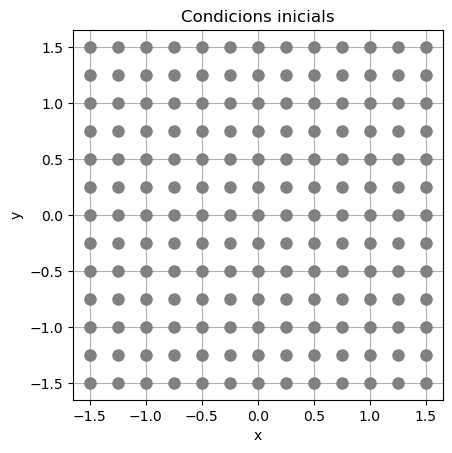

In [10]:
grafica_punts(condicions_inicials)

### 2. Generar $n$ trajectòries, una per a cada posició inicial

Cada trajectòria és la solució de l'EDO avaluada en $k$=`t_steps` instants de temps.

In [11]:
def generar_trajectories(edo, 
                         condicions_inicials: np.ndarray,
                         t_span: Tuple[float, float], 
                         t_valors: np.ndarray) -> np.ndarray:
    """
    Paràmetres:
        edo: funció que representa el camp vectorial d'una EDO
        num_trajectories: nombre de trajectòries a generar
        condicions_inicials: llista que conté condicions inicials [x0,y0]
        t_valors: np.array[float], conté els instants de temps on avaluem l'EDO
        
    """
    trajectories = np.zeros((num_trajectories, t_steps, dimensio))
    for i, ci in enumerate(condicions_inicials):
        valor_random = 1 # np.random.uniform(0, 2)
        arguments_extra = (valor_random, epsilon, funcio_soroll)
        sol = solve_ivp(edo, t_span, ci,
                        t_eval=t_valors, 
                        args=arguments_extra)
        trajectoria = np.vstack([sol.y[0], sol.y[1]])
        trajectoria = trajectoria.T
        # print(f'{trajectoria = }')
        trajectories[i] = trajectoria
    return trajectories

In [12]:
trajectories = generar_trajectories(edo_duffing_soroll,
                                    condicions_inicials,
                                    t_span,
                                    t_valors)
print(trajectories.shape)
# grafica_trajectories(trajectories)

(169, 100, 2)


### 3. Calcular distància $r_{ij}$ entre trajectòries

In [13]:
def calcula_distancia(trajectoria_i: np.ndarray, trajectoria_j: np.ndarray, t_valors: np.ndarray) -> float:
    distancia = 0
    num_t_steps = len(t_valors)
    dist_k = np.linalg.norm(trajectoria_i[0] - trajectoria_j[0]) # Norma euclidia de vectors en R^2
    for k in range(num_t_steps - 1):
        dist_k_plus_one = np.linalg.norm(trajectoria_i[k+1] - trajectoria_j[k+1])
        distancia += (t_valors[k+1] - t_valors[k]) * (dist_k + dist_k_plus_one) / 2
        dist_k = dist_k_plus_one
    t_start = t_valors[0]
    t_end = t_valors[-1]
    return distancia / (t_end - t_start)

### 4. Crear graf $G = (V, E, W)$

Els vèrtexs són cadascuna de les $n$ trajectòries: $V=\{v_1,...,v_n\}$.

Cada aresta $e_{ij}\in E\subseteq V\times V$ està associada al pes $w_{ij}\in W\in\R^{n\times n}$, on $W$ és la matriu de similaritat i $w_{ij} = 1/r_{ij}$. Cada pes representa quant de properes són dues trajectòries ($0 \rightarrow$ poc, i $\infty \rightarrow$ molt).

In [14]:
def calcula_matriu_similaritat(trajectories: np.ndarray, t_valors: np.ndarray, constant_K: float = 1e4) -> np.ndarray:
    num_trajectories = len(trajectories)
    matriu_similaritat = np.zeros((num_trajectories, num_trajectories))
    for i in range(num_trajectories):
        matriu_similaritat[i][i] = constant_K # Omplim la diagonal amb una constant gran
        for j in range(i+1, num_trajectories):
            w_ij = 1 / calcula_distancia(trajectories[i], trajectories[j], t_valors)
            matriu_similaritat[i][j] = w_ij
            matriu_similaritat[j][i] = w_ij
    return matriu_similaritat

In [ ]:
matriu_similaritat_W = calcula_matriu_similaritat(trajectories, t_valors)
print(matriu_similaritat_W.shape)

(169, 169)


### 5. Calcular el grau

In [16]:
def calcula_grau(vertex: int, matriu_similaritat: np.ndarray) -> float:
    return sum(matriu_similaritat[vertex][j] for j in range(len(matriu_similaritat)))

In [17]:
def calcula_volum(vertexs: Iterable[int], matriu_similaritat: np.ndarray) -> np.ndarray:
    return np.diag([calcula_grau(vertex, matriu_similaritat) for vertex in vertexs])

In [18]:
def calcula_matriu_grau(matriu_similaritat: np.ndarray) -> np.ndarray:
    tots_els_vertexs = range(len(matriu_similaritat))
    return calcula_volum(tots_els_vertexs, matriu_similaritat)

In [19]:
matriu_grau_D = calcula_matriu_grau(matriu_similaritat_W)
print(np.shape(matriu_grau_D))

(169, 169)


### 6. Fer que la matriu de similiaritat $W$ sigui _sparse_ usant $k$-nearest neighbors [opcional]

O bé quedarse només amb els pesos $w_{ij}$ més grans que una tolerància $\epsilon$. (Aquesta $\epsilon$ és diferent de l'$\epsilon$ de l'EDO). L'obectiu de tornar la matriu sparse és per reduir la memòria que ocupa i poder emmagatzemar-la.

#### Trobar la partició que satisfà _mincut_

In [22]:
def pes_del_tall(vertexs_A: Iterable[int], vertexs_B: Iterable[int]) -> float:
    return sum(matriu_similaritat_W[i][j] for i in vertexs_A for j in vertexs_B)

In [ ]:
def exemple():
    meitatA = range(num_trajectories//2)
    meitatB = range(num_trajectories//2, num_trajectories)
    print(pes_del_tall(meitatA, meitatB))

4320.386559238791


### 7. Descomposició espectral: $Lu =λDu$

In [27]:
matriu_laplacia_L = matriu_grau_D - matriu_similaritat_W
print(matriu_laplacia_L.shape)

(169, 169)


In [28]:
vaps = np.linalg.eigvals(matriu_laplacia_L)
num_vaps = len(vaps)
vaps.sort()
print(vaps.shape)

(169,)


### 8. Estimació del nombre de clústers $k$ = argmin [max($g_i$)]

In [38]:
vaps_diferencies = np.array([vaps[i+1] - vaps[i] for i in range(num_vaps - 1)])
print(vaps_diferencies[:10])

[79.26984853  1.68470927  2.29529866  1.78483174  2.39571429  0.99194137
  1.73779613  0.28523569  1.32399407  0.96348022]


In [34]:
k = np.argmax(vaps_diferencies)
print(k)

0
